# ガボール関数とその可視化

In [26]:
import sys
import matplotlib.pyplot as plt
import numpy as np
sys.path.append('../src')
from data_generate import calculate_s_x, add_gaussian_noise, add_poisson_noise#読み込み

## ガボール関数の適用

In [27]:
xm_val = 0.0
fn_val = 0.52
sigma_val = 1.0
noise_level = 0.1   # ガウスノイズの標準偏差
poisson_scale = 5.0  # ポアソンノイズの強度（大きいほど相対ノイズ小）
num_points = 1000  # xの点数
x_min, x_max = -5, 5  # xの範囲
# xの範囲を作成
x_range = np.linspace(x_min, x_max, num_points)

# S(x) を一括計算（ベクトル化）
s_x_values = calculate_s_x(x_range, xm_val, fn_val, sigma_val)
print(f"len(s_x_values): {len(s_x_values)}")

# ガウスノイズ版・ポアソンノイズ版をそれぞれ生成
s_x_gauss = add_gaussian_noise(s_x_values, sigma=noise_level)
s_x_poisson = add_poisson_noise(s_x_values, scale=poisson_scale)

len(s_x_values): 1000


## 可視化

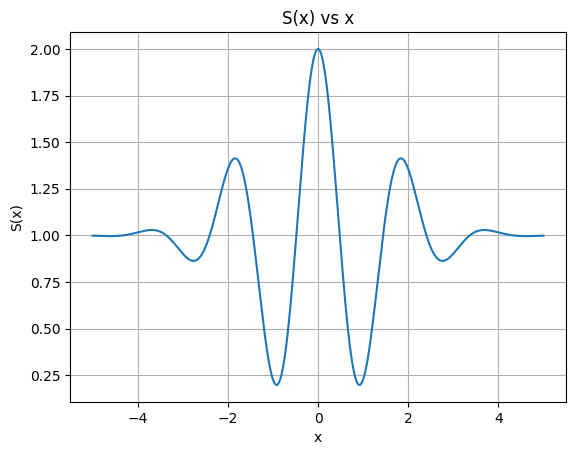

In [28]:
plt.plot(x_range, s_x_values)
plt.title('S(x) vs x')
plt.xlabel('x')
plt.ylabel('S(x)')
plt.grid()
plt.show()

## ガウスノイズを加えたガボール関数の可視化

$$Observe(x) = S(x) + \sigma, \quad \sigma \sim N(0, 0.01)．$$

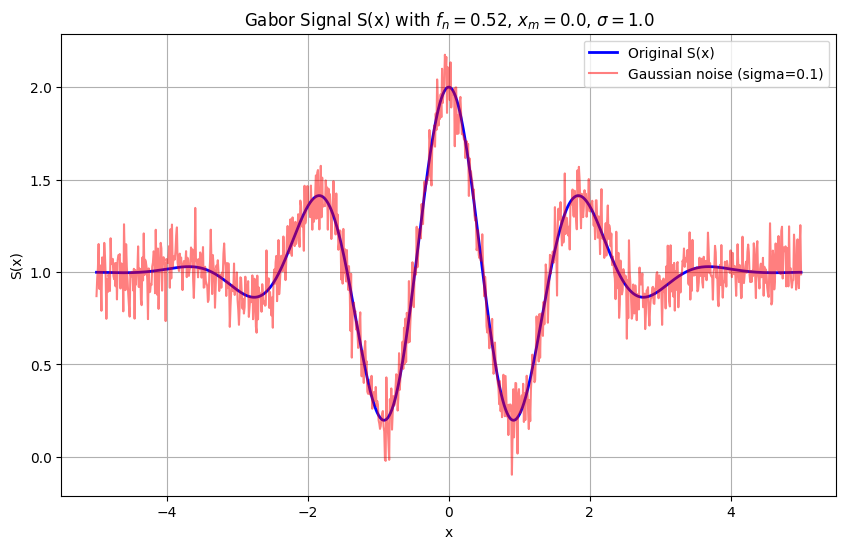

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(x_range, s_x_values, label='Original S(x)', color='blue', linewidth=2)
plt.plot(x_range, s_x_gauss, label=f'Gaussian noise (sigma={noise_level})', color='red', alpha=0.5)

plt.title(f'Gabor Signal S(x) with $f_n={fn_val}$, $x_m={xm_val}$, $\\sigma={sigma_val}$')
plt.xlabel('x')
plt.ylabel('S(x)')
plt.legend()
plt.grid(True)
plt.show()

## ポアソンノイズを加えたガボール関数の可視化
$$Observe(x) \sim Poisson(scale \cdot S(x))．$$

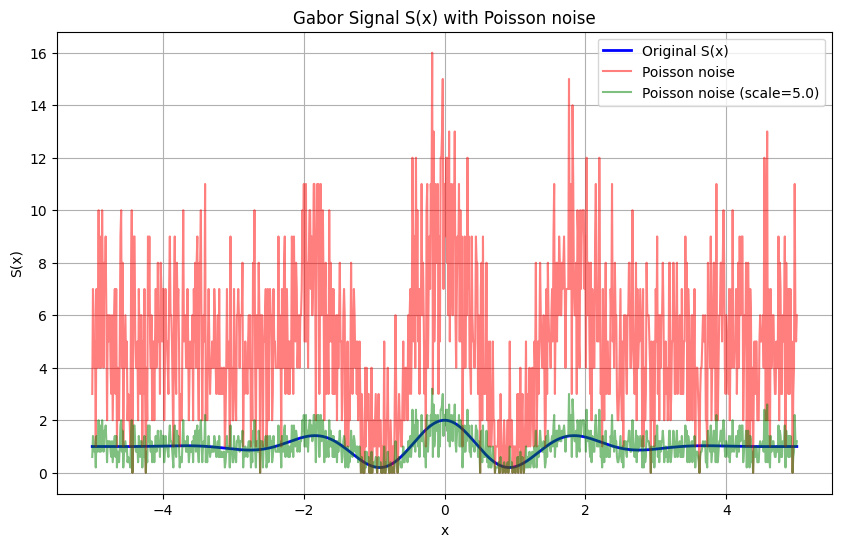

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(x_range, s_x_values, label='Original S(x)', color='blue', linewidth=2)
plt.plot(x_range, s_x_poisson, label=f'Poisson noise', color='red', alpha=0.5)
plt.plot(x_range, s_x_poisson/poisson_scale, label=f'Poisson noise (scale={poisson_scale})', color='green', alpha=0.5)

plt.title(f'Gabor Signal S(x) with Poisson noise')
plt.xlabel('x')
plt.ylabel('S(x)')
plt.legend()
plt.grid(True)
plt.show()

# ノイズデータの保存

In [31]:
from pathlib import Path

SIMULATED_DATA_DIR = Path('../simulated_data')
print(f'保存先ベースディレクトリ: {SIMULATED_DATA_DIR}')

保存先ベースディレクトリ: ../simulated_data


## データの保存

In [32]:
# 保存するノイズの種類を選択: 'gauss' または 'poisson'
noise = 'poisson'

save = True  # True にすると simulated_data/ 以下に保存

data_map = {
    'gauss':   s_x_gauss,
    'poisson': s_x_poisson,
}

if noise not in data_map:
    raise ValueError(f"noise は 'gauss' か 'poisson' を指定してください（現在: {noise!r})")

if save:
    # ディレクトリ名をパラメータから生成
    if noise == 'gauss':
        dir_name = f'gauss_xm{xm_val}_fn{fn_val}_sigma{sigma_val}'
        params = {
            'noise_model': 'gauss',
            'xm': xm_val, 'fn': fn_val, 'sigma': sigma_val,
            'noise_level': noise_level,
                'x_min': x_min, 'x_max': x_max, 'n_points': num_points,
            }
    else:
        dir_name = f'poisson_xm{xm_val}_fn{fn_val}_sigma{sigma_val}_scale{poisson_scale}'
        params = {
            'noise_model': 'poisson',
            'xm': xm_val, 'fn': fn_val, 'sigma': sigma_val,
            'poisson_scale': poisson_scale,
            'x_min': x_min, 'x_max': x_max, 'n_points': num_points,
        }

    save_dir = SIMULATED_DATA_DIR / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

    # params.json を保存
    with open(save_dir / 'params.json', 'w', encoding='utf-8') as f:
        import json as _json
        _json.dump(params, f, indent=4, ensure_ascii=False)

    # data.txt を保存
    with open(save_dir / 'data.txt', 'w', encoding='utf-8') as f:
        for x_val, s_val in zip(x_range, data_map[noise]):
            f.write(f'{x_val} {s_val}\n')

    print(f'保存しました: {save_dir}')
    print(f'  params.json: {params}')
else:
    print(f'save=False のため保存をスキップしました (選択中: {noise} ノイズ)')


保存しました: ../simulated_data/poisson_xm0.0_fn0.52_sigma1.0_scale5.0
  params.json: {'noise_model': 'poisson', 'xm': 0.0, 'fn': 0.52, 'sigma': 1.0, 'poisson_scale': 5.0, 'x_min': -5, 'x_max': 5, 'n_points': 1000}
